# Практическая работа 7 Ансамблевое обучение

Албахтин И.В., ИНБО-12-23. Задача: классифицировать семь типов дефектов стальных
пластин, сравнить бэггинг деревьев и градиентный бустинг на одних данных.

Данные: Buscema M., Terzi S., Tastle W. (2010), Steel Plates Faults, UCI,
https://doi.org/10.24432/C5J88N, CC BY 4.0. Это отдельное задание по машинному
обучению, а не практика ППОИС 7 по проектированию БД.

Открыть этот `.ipynb` в Google Colab, выбрать CPU и выполнить все ячейки.
GPU не требуется для этих реализаций scikit-learn. Проверка уникальности
датасета в учебной группе выполняется отдельно: список выбранных группой
данных не содержится в исходном задании.


In [1]:
import sys, subprocess
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'scikit-learn==1.9.1', 'matplotlib==3.11.2', 'pandas==3.0.1'])
print('Execution environment:', 'Google Colab' if IN_COLAB else 'local verification')


Execution environment: local verification


## 1 Загрузка и проверка данных

Все 27 признаков числовые. Семь последних столбцов — индикаторы целевого
класса: их нельзя включать в X. Для каждой записи проверяется ровно один
активный целевой индикатор. Исходный архив и таблица сохраняются с SHA-256.


In [2]:
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile
from io import BytesIO
import hashlib, json, platform, os, time, statistics
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.base import clone
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)
from threadpoolctl import threadpool_limits, threadpool_info

OUTPUT = Path('outputs'); OUTPUT.mkdir(exist_ok=True)
DATA = Path('data'); DATA.mkdir(exist_ok=True)
URL = 'https://archive.ics.uci.edu/static/public/198/steel+plates+faults.zip'
archive = DATA / 'steel_plates_faults.zip'
if not archive.exists():
    urlretrieve(URL, archive)
assert hashlib.sha256(archive.read_bytes()).hexdigest() == 'cb8eb9859198b63f053e443513036b401746fa517ef58bd17c846c6741c93919'
with ZipFile(archive) as z:
    raw = z.read('Faults.NNA')
    variable_names = z.read('Faults27x7_var').decode().split()
data = pd.read_csv(BytesIO(raw), sep=r'\s+', header=None, names=variable_names)
assert data.shape == (1941, 34), data.shape
X = data.iloc[:, :27].astype(float)
indicators = data.iloc[:, 27:]
assert set(np.unique(indicators.to_numpy())) == {0, 1}
assert indicators.sum(axis=1).eq(1).all()
assert not data.isna().any().any()
assert np.isfinite(X.to_numpy()).all()
LABELS = list(indicators.columns)
y = np.argmax(indicators.to_numpy(), axis=1)
manifest = {'source': URL, 'citation': 'Buscema, Terzi, Tastle (2010), DOI 10.24432/C5J88N',
            'license': 'CC BY 4.0', 'archive_sha256': hashlib.sha256(archive.read_bytes()).hexdigest(),
            'table_sha256': hashlib.sha256(raw).hexdigest(), 'rows':len(data),
            'features':list(X.columns), 'target_classes':LABELS,
            'class_counts':{LABELS[i]:int((y==i).sum()) for i in range(7)},
            'missing_values':int(data.isna().sum().sum()),
            'duplicate_feature_rows':int(X.duplicated().sum()),
            'duplicate_full_rows':int(data.duplicated().sum())}
print(json.dumps(manifest, ensure_ascii=False, indent=2))
display(data.head())


{
  "source": "https://archive.ics.uci.edu/static/public/198/steel+plates+faults.zip",
  "citation": "Buscema, Terzi, Tastle (2010), DOI 10.24432/C5J88N",
  "license": "CC BY 4.0",
  "archive_sha256": "cb8eb9859198b63f053e443513036b401746fa517ef58bd17c846c6741c93919",
  "table_sha256": "08994f5b0185a8e6cc22afe9910fd36834990fb1ca30852ed79012a832fbff55",
  "rows": 1941,
  "features": [
    "X_Minimum",
    "X_Maximum",
    "Y_Minimum",
    "Y_Maximum",
    "Pixels_Areas",
    "X_Perimeter",
    "Y_Perimeter",
    "Sum_of_Luminosity",
    "Minimum_of_Luminosity",
    "Maximum_of_Luminosity",
    "Length_of_Conveyer",
    "TypeOfSteel_A300",
    "TypeOfSteel_A400",
    "Steel_Plate_Thickness",
    "Edges_Index",
    "Empty_Index",
    "Square_Index",
    "Outside_X_Index",
    "Edges_X_Index",
    "Edges_Y_Index",
    "Outside_Global_Index",
    "LogOfAreas",
    "Log_X_Index",
    "Log_Y_Index",
    "Orientation_Index",
    "Luminosity_Index",
    "SigmoidOfAreas"
  ],
  "target_classes":

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0


## 2 Единое разбиение без утечки целевой переменной

20% данных — отложенный тест; stratify сохраняет представленность классов.
Подбор параметров использует только оставшиеся 80% и одинаковые три
стратифицированных фолда. Тест не участвует в выборе параметров.
Для деревьев масштабирование не требуется. Проверка хэшей строк дополнительно
исключает идентичные признаки одновременно в train и test.


Train: (1552, 27) Test: (389, 27)


,class,all,train,test
0,Pastry,158,126,32
1,Z_Scratch,190,152,38
2,K_Scatch,391,313,78
3,Stains,72,58,14
4,Dirtiness,55,44,11
5,Bumps,402,321,81
6,Other_Faults,673,538,135


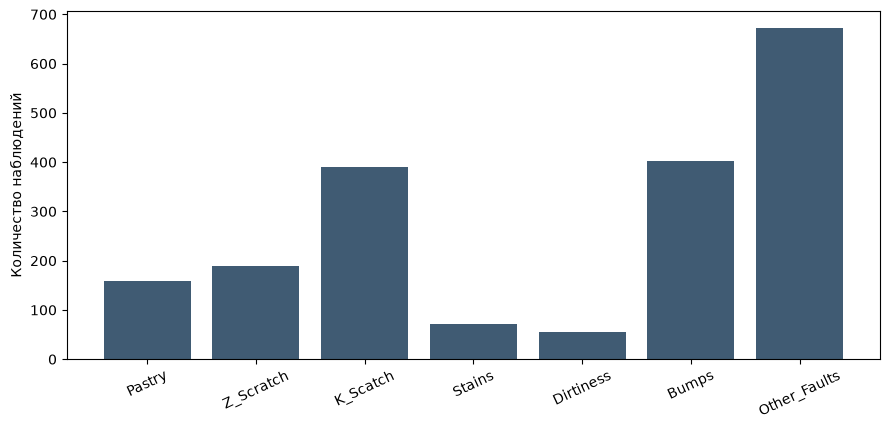

In [3]:
SEED = 42
train_idx, test_idx = train_test_split(np.arange(len(X)), test_size=.2,
                                      stratify=y, random_state=SEED)
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
assert set(train_idx).isdisjoint(test_idx)
row_hash = pd.util.hash_pandas_object(X, index=False).to_numpy()
assert set(row_hash[train_idx]).isdisjoint(row_hash[test_idx]), 'Duplicate features cross the split'
splits = list(StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED).split(X_train, y_train))
split_manifest = {'seed':SEED, 'train_rows':len(train_idx), 'test_rows':len(test_idx),
                  'train_indices':train_idx.tolist(), 'test_indices':test_idx.tolist(),
                  'cv_folds':3, 'cross_split_duplicate_features':False}
print('Train:', X_train.shape, 'Test:', X_test.shape)
display(pd.DataFrame({'class':LABELS,
                      'all':np.bincount(y, minlength=7),
                      'train':np.bincount(y_train, minlength=7),
                      'test':np.bincount(y_test, minlength=7)}))
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.bar(LABELS, np.bincount(y, minlength=7), color='#405b73')
ax.set_ylabel('Количество наблюдений'); ax.tick_params(axis='x', rotation=25)
fig.tight_layout(); fig.savefig(OUTPUT/'01_classes.png', dpi=200); plt.show()


## 3 Бэггинг и бустинг

Бэггинг: 80 независимых деревьев, bootstrap-подвыборка 80% строк для каждого
дерева; финальный класс выбирается по усреднённым вероятностям.
Бустинг: последовательное построение деревьев для уменьшения log loss;
для многоклассовой задачи на каждой итерации создаётся дерево для каждого класса.
Размер сеток одинаковый — четыре комбинации и три фолда (12 проверок на алгоритм).
Критерий выбора — macro-F1, чтобы учитывать малочисленные классы.


In [4]:
candidates = {
    'Bagging': (BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=SEED),
        n_estimators=80, max_samples=.8, bootstrap=True, n_jobs=1, random_state=SEED),
        {'estimator__max_depth':[6, None], 'estimator__min_samples_leaf':[2, 5]}),
    'Boosting': (GradientBoostingClassifier(learning_rate=.1, subsample=1., random_state=SEED),
        {'n_estimators':[80, 160], 'max_depth':[2, 3]})}
best, searches, search_summary = {}, {}, []
with threadpool_limits(limits=1):
    for name, (estimator, grid) in candidates.items():
        start = time.perf_counter()
        search = GridSearchCV(estimator, grid, scoring='f1_macro', cv=splits,
                              n_jobs=1, refit=False, error_score='raise', return_train_score=True)
        search.fit(X_train, y_train)
        elapsed = time.perf_counter()-start
        best[name] = clone(estimator).set_params(**search.best_params_)
        searches[name] = search
        pd.DataFrame(search.cv_results_).to_csv(OUTPUT/f'cv_{name.lower()}.csv', index=False)
        search_summary.append({'algorithm':name, 'best_params':search.best_params_,
            'best_cv_f1_macro':float(search.best_score_),
            'cv_std':float(search.cv_results_['std_test_score'][search.best_index_]),
            'search_seconds':elapsed, 'candidates':len(search.cv_results_['params'])})
display(pd.DataFrame(search_summary))


,algorithm,best_params,best_cv_f1_macro,cv_std,search_seconds,candidates
0,Bagging,"{'estimator__max_depth': None, 'estimator__min...",0.766865,0.012496,4.036103,4
1,Boosting,"{'max_depth': 3, 'n_estimators': 160}",0.781251,0.010614,24.790015,4


## 4 Одинаковые измерения времени и качества

Три повторных обучения каждой выбранной конфигурации; порядок чередуется.
Замер fit не включает загрузку данных и поиск параметров. Замер predict
включает предсказание всех 389 тестовых строк. Параллелизм ограничен одним
потоком; фиксированный random_state сохраняет предсказания между повторами.
Время — фактическое время конкретного CPU, а не универсальная оценка.


In [5]:
measurements = {name:[] for name in best}
predictions, fitted = {}, {}
with threadpool_limits(limits=1):
    training_threadpools = [{k:v for k,v in item.items() if k != 'filepath'} for item in threadpool_info()]
    for repeat in range(3):
        order = list(best) if repeat%2 == 0 else list(reversed(best))
        for name in order:
            model = clone(best[name])
            start = time.perf_counter(); model.fit(X_train, y_train)
            fit_seconds = time.perf_counter()-start
            start = time.perf_counter(); prediction = model.predict(X_test)
            predict_seconds = time.perf_counter()-start
            if name in predictions:
                assert np.array_equal(prediction, predictions[name])
            predictions[name], fitted[name] = prediction, model
            measurements[name].append({'repeat':repeat+1,'fit_seconds':fit_seconds,
                                        'predict_seconds':predict_seconds})
rows, per_class, matrices = [], {}, {}
for name, model in fitted.items():
    prediction = predictions[name]
    timings = measurements[name]
    rows.append({'algorithm':name,
        'accuracy':accuracy_score(y_test, prediction),
        'balanced_accuracy':balanced_accuracy_score(y_test, prediction),
        'test_f1_macro':f1_score(y_test,prediction,average='macro'),
        'train_f1_macro':f1_score(y_train,model.predict(X_train),average='macro'),
        'fit_median_seconds':statistics.median(t['fit_seconds'] for t in timings),
        'fit_min_seconds':min(t['fit_seconds'] for t in timings),
        'fit_max_seconds':max(t['fit_seconds'] for t in timings),
        'predict_median_seconds':statistics.median(t['predict_seconds'] for t in timings)})
    per_class[name] = classification_report(y_test,prediction,labels=range(7),target_names=LABELS,output_dict=True,zero_division=0)
    matrices[name] = confusion_matrix(y_test,prediction,labels=range(7)).tolist()
    pd.DataFrame({'source_row':test_idx,'true_class':y_test,'predicted_class':prediction}).to_csv(OUTPUT/f'predictions_{name.lower()}.csv',index=False)
baseline_rows = []
for name, model in [('Most frequent',DummyClassifier(strategy='most_frequent')),
                    ('One tree',DecisionTreeClassifier(max_depth=8,min_samples_leaf=2,random_state=SEED))]:
    model.fit(X_train,y_train); prediction=model.predict(X_test)
    baseline_rows.append({'algorithm':name,'accuracy':accuracy_score(y_test,prediction),
                         'test_f1_macro':f1_score(y_test,prediction,average='macro')})
display(pd.DataFrame(rows)); display(pd.DataFrame(baseline_rows))


,algorithm,accuracy,balanced_accuracy,test_f1_macro,train_f1_macro,fit_median_seconds,fit_min_seconds,fit_max_seconds,predict_median_seconds
0,Bagging,0.791774,0.804057,0.811931,0.979067,0.589319,0.586019,0.591103,0.006413
1,Boosting,0.809769,0.821753,0.826791,0.997508,4.715257,4.714289,4.717341,0.002923


,algorithm,accuracy,test_f1_macro
0,Most frequent,0.347044,0.073610
1,One tree,0.717224,0.744199


## 5 Ошибки по классам и визуальное сравнение

Строки confusion matrix — истинные классы, столбцы — предсказанные.
Macro-F1 одинаково учитывает каждый класс; accuracy сильнее зависит от частот.
Повторные замеры времени не являются независимыми выборками для оценки качества:
качество здесь измерено на одном фиксированном тесте.


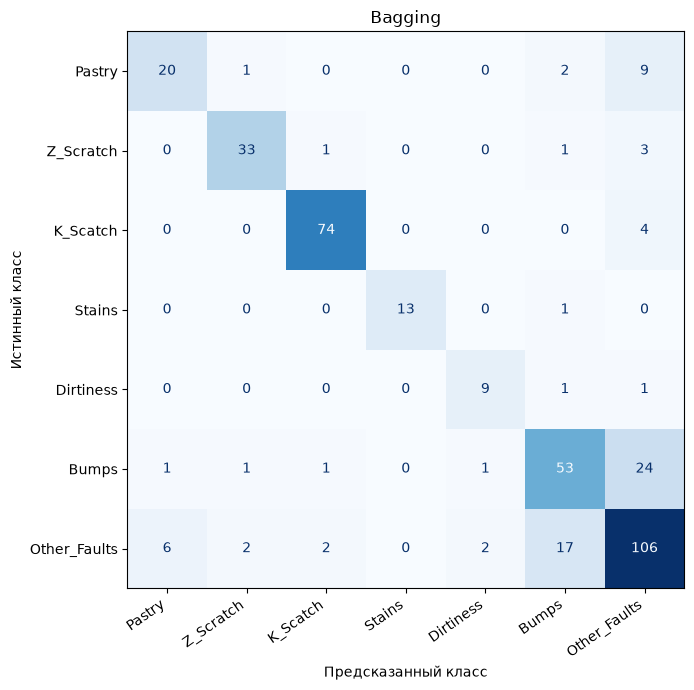

,precision,recall,f1-score,support
Pastry,0.740741,0.625000,0.677966,32.000000
Z_Scratch,0.891892,0.868421,0.880000,38.000000
K_Scatch,0.948718,0.948718,0.948718,78.000000
Stains,1.000000,0.928571,0.962963,14.000000
Dirtiness,0.750000,0.818182,0.782609,11.000000
Bumps,0.706667,0.654321,0.679487,81.000000
Other_Faults,0.721088,0.785185,0.751773,135.000000
accuracy,0.791774,0.791774,0.791774,0.791774
macro avg,0.822729,0.804057,0.811931,389.000000
weighted avg,0.792886,0.791774,0.791139,389.000000


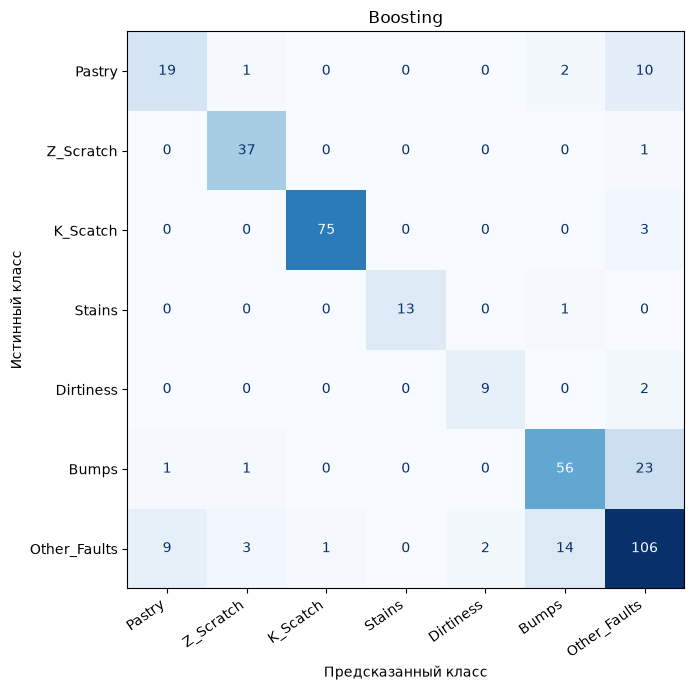

,precision,recall,f1-score,support
Pastry,0.655172,0.593750,0.622951,32.000000
Z_Scratch,0.880952,0.973684,0.925000,38.000000
K_Scatch,0.986842,0.961538,0.974026,78.000000
Stains,1.000000,0.928571,0.962963,14.000000
Dirtiness,0.818182,0.818182,0.818182,11.000000
Bumps,0.767123,0.691358,0.727273,81.000000
Other_Faults,0.731034,0.785185,0.757143,135.000000
accuracy,0.809769,0.809769,0.809769,0.809769
macro avg,0.834187,0.821753,0.826791,389.000000
weighted avg,0.810391,0.809769,0.808903,389.000000


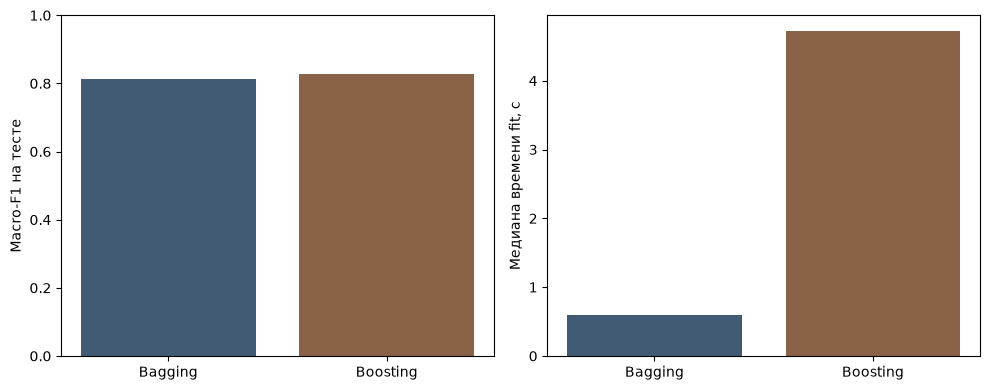

In [6]:
for name in fitted:
    fig, ax = plt.subplots(figsize=(8.5,7))
    ConfusionMatrixDisplay(np.array(matrices[name]),display_labels=LABELS).plot(ax=ax, colorbar=False, cmap='Blues',values_format='d')
    ax.set_title(name); ax.set_xlabel('Предсказанный класс'); ax.set_ylabel('Истинный класс')
    plt.setp(ax.get_xticklabels(),rotation=35,ha='right')
    fig.tight_layout(); fig.savefig(OUTPUT/f'02_confusion_{name.lower()}.png',dpi=200); plt.show()
    display(pd.DataFrame(per_class[name]).T)
fig, axes = plt.subplots(1,2,figsize=(10,4))
axes[0].bar([r['algorithm'] for r in rows],[r['test_f1_macro'] for r in rows],color=['#405b73','#8a6247'])
axes[0].set_ylim(0,1); axes[0].set_ylabel('Macro-F1 на тесте')
axes[1].bar([r['algorithm'] for r in rows],[r['fit_median_seconds'] for r in rows],color=['#405b73','#8a6247'])
axes[1].set_ylabel('Медиана времени fit, с')
fig.tight_layout(); fig.savefig(OUTPUT/'03_comparison.png',dpi=200); plt.show()


## 6 Проверяемые результаты и вывод

Результат сохраняется вместе с исходными измерениями, индексами разбиения,
версией библиотек и средой запуска. Вывод формируется из выполненных измерений.
После Colab-запуска скачать папку outputs и сохранить выполненный notebook
через Файл → Скачать → Скачать IPYNB. Локальные результаты не выдаются за Colab.


In [7]:
winner = max(rows,key=lambda r:r['test_f1_macro'])
fastest = min(rows,key=lambda r:r['fit_median_seconds'])
environment = {'location':'Google Colab' if IN_COLAB else 'local Windows verification',
               'platform':platform.platform(),'python':platform.python_version(),
               'sklearn':sklearn.__version__,'numpy':np.__version__,'pandas':pd.__version__,
               'logical_cpus':os.cpu_count(),'thread_limit':1,'training_threadpools':training_threadpools}
results = {'executed_at':datetime.now(timezone.utc).isoformat(),'environment':environment,
           'source':manifest,'split':split_manifest,'search':search_summary,
           'measurements':measurements,'metrics':rows,'baselines':baseline_rows,
           'per_class':per_class,'confusion_matrices':matrices,
           'best_test_macro_f1_algorithm':winner['algorithm'],
           'fastest_fit_algorithm':fastest['algorithm']}
(OUTPUT/'results.json').write_text(json.dumps(results,ensure_ascii=False,indent=2),encoding='utf-8')
print(f"На фиксированном тесте лучший macro-F1: {winner['algorithm']} ({winner['test_f1_macro']:.4f}).")
print(f"Меньшая медиана времени fit: {fastest['algorithm']} ({fastest['fit_median_seconds']:.3f} с).")
print('Выбор модели зависит от требований к качеству редких классов и времени, а не только от accuracy.')
print('Один holdout не доказывает универсального превосходства. Вывод относится к этому набору и разбиению.')
print('ALL CELLS COMPLETED; results.json saved')


На фиксированном тесте лучший macro-F1: Boosting (0.8268).
Меньшая медиана времени fit: Bagging (0.589 с).
Выбор модели зависит от требований к качеству редких классов и времени, а не только от accuracy.
Один holdout не доказывает универсального превосходства. Вывод относится к этому набору и разбиению.
ALL CELLS COMPLETED; results.json saved
